In [1]:
### 라이브러리 임포트
import os
import json
import glob
import random
import cv2
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.font_manager as fm

In [3]:
### 폰트 설정

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [10]:
### 상위 폴더 기준 raw 폴더 안의 이미지 경로 탐색

import glob
from PIL import Image

image_paths = glob.glob("../data/raw/**/*.jpg", recursive=True)
if not image_paths:
    image_paths = glob.glob("../data/raw/**/*.png", recursive=True)

if image_paths:
    img = Image.open(image_paths[0])
    print(f"파일 경로: {image_paths[0]}")
    print(f"원본 해상도(크기 - 가로 x 세로): {img.size}")
else:
    print("이미지 파일을 찾지 못했습니다.")

파일 경로: ../data/raw/sprint_ai_project1_data/test_images/1186.png
원본 해상도(크기 - 가로 x 세로): (976, 1280)


In [11]:
# 실제 파일 개수, 실제 JSON 개수, 파일 구조 확인 과정

import os
import glob

base_path = "../data"

print("=== 파일 구조 확인 (상위 2단계) ===")
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    if level <= 2:
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/ (파일 수: {len(files)}개)")

print("\n=== 실제 파일 및 JSON 개수 집계 ===")
jpg_files = glob.glob(f"{base_path}/**/*.jpg", recursive=True)
png_files = glob.glob(f"{base_path}/**/*.png", recursive=True)
json_files = glob.glob(f"{base_path}/**/*.json", recursive=True)

print(f"- JPG 이미지 개수: {len(jpg_files)}개")
print(f"- PNG 이미지 개수: {len(png_files)}개")
print(f"- JSON 어노테이션 개수: {len(json_files)}개")

=== 파일 구조 확인 (상위 2단계) ===
data/ (파일 수: 1개)
    processed/ (파일 수: 1개)
    raw/ (파일 수: 1개)
        sprint_ai_project1_data/ (파일 수: 0개)

=== 실제 파일 및 JSON 개수 집계 ===
- JPG 이미지 개수: 0개
- PNG 이미지 개수: 1074개
- JSON 어노테이션 개수: 763개


In [12]:
# 이미지 안에 있는 정보 확인

import json
import glob

# 데이터셋 내 JSON 파일 중 첫 번째 파일 찾기
json_files = glob.glob("../data/**/*.json", recursive=True)

if json_files:
    sample_json_path = json_files[0]
    print(f"샘플 JSON 파일 경로: {sample_json_path}\n")
    
    with open(sample_json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    print("=== JSON 최상위 키 목록 ===")
    print(list(data.keys()))
    
    if "images" in data:
        print("\n=== 'images' 키 내부 정보 (첫 번째 항목) ===")
        print(json.dumps(data["images"][0], indent=4, ensure_ascii=False))
    else:
        print("\n이 JSON 파일에는 'images' 키가 없음. 최상위 데이터 구조를 확인해보기.")
        print(json.dumps(data, indent=4, ensure_ascii=False)[:500]) # 일부 출력
else:
    print("JSON 파일을 찾지 못함.")

샘플 JSON 파일 경로: ../data/raw/sprint_ai_project1_data/train_annotations/K-003351-016232-033880_json/K-003351/K-003351-016232-033880_0_2_0_2_75_000_200.json

=== JSON 최상위 키 목록 ===
['images', 'type', 'annotations', 'categories']

=== 'images' 키 내부 정보 (첫 번째 항목) ===
{
    "file_name": "K-003351-016232-033880_0_2_0_2_75_000_200.png",
    "width": 976,
    "height": 1280,
    "imgfile": "K-003351-016232-033880_0_2_0_2_75_000_200.png",
    "drug_N": "K-003351",
    "drug_S": "정상알약",
    "back_color": "연회색 배경",
    "drug_dir": "앞면",
    "light_color": "주백색",
    "camera_la": 75,
    "camera_lo": 0,
    "size": 200,
    "dl_idx": "3351",
    "dl_mapping_code": "K-003351",
    "dl_name": "일양하이트린정 2mg",
    "dl_name_en": "Hytrin Tab. 2mg Ilyang",
    "img_key": "http://connectdi.com/design/img/drug/147765842976900148.jpg",
    "dl_material": "테라조신염산염수화물",
    "dl_material_en": "Terazosin Hydrochloride Hydrate",
    "dl_custom_shape": "정제, 저작정",
    "dl_company": "일양약품(주)",
    "dl_company_en": "Ilya

In [13]:
# annotation 안에 있는 정보 확인

import json
import glob

json_files = glob.glob("../data/**/*.json", recursive=True)

if json_files:
    sample_json_path = json_files[0]
    
    with open(sample_json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    if "annotations" in data:
        print("=== 'annotations' 키 내부 정보 (첫 번째 항목) ===")
        print(json.dumps(data["annotations"][0], indent=4, ensure_ascii=False))
    elif "annotation" in data:
        print("=== 'annotation' 키 내부 정보 (첫 번째 항목) ===")
        print(json.dumps(data["annotation"][0], indent=4, ensure_ascii=False))
    else:
        print("이 JSON 파일에는 어노테이션 관련 키가 명시되어 있지 않음. 전체 키 구조를 다시 확인해 보기.")
        print("포함된 키들:", list(data.keys()))
else:
    print("JSON 파일을 찾지 못함.")

=== 'annotations' 키 내부 정보 (첫 번째 항목) ===
{
    "area": 35532,
    "iscrowd": 0,
    "bbox": [
        317,
        186,
        189,
        188
    ],
    "category_id": 3351,
    "ignore": 0,
    "segmentation": [],
    "id": 56,
    "image_id": 14
}


In [16]:
# category_id 약 이름 매핑 확인

import json
import glob

json_files = glob.glob("../data/**/*.json", recursive=True)

if json_files:
    sample_json_path = json_files[0]
    
    with open(sample_json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    # categories 또는 유사한 키가 있는지 확인
    category_keys = [k for k in data.keys() if 'cat' in k.lower() or 'class' in k.lower() or 'item' in k.lower()]
    print(f"카테고리/클래스 관련 잠재적 키 목록: {category_keys}")
    
    found = False
    for key in category_keys:
        print(f"\n=== '{key}' 키 내부 정보 (상위 5개) ===")
        items = data[key]
        if isinstance(items, list):
            for item in items[:5]:
                print(item)
            found = True
        elif isinstance(items, dict):
            print(list(items.items())[:5])
            found = True
            
    if not found:
        print("\n별도의 카테고리 리스트가 이 JSON 파일에 없음. 최상위 키 구조:")
        print(list(data.keys()))
else:
    print("JSON 파일을 찾지 못함.")

카테고리/클래스 관련 잠재적 키 목록: ['categories']

=== 'categories' 키 내부 정보 (상위 5개) ===
{'supercategory': 'pill', 'id': 3351, 'name': '일양하이트린정 2mg'}


In [17]:
# 클래스 ID와 약 이름 매핑 (매핑 테이블 생성)

import json
import glob
import pandas as pd

# JSON 파일 경로 전체 탐색
json_files = glob.glob("../data/**/*.json", recursive=True)

category_map = {}

for jf in json_files:
    try:
        with open(jf, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        # COCO 포맷 기준 categories 키 탐색
        if "categories" in data:
            for cat in data["categories"]:
                cat_id = cat.get("id")
                cat_name = cat.get("name")
                if cat_id is not None and cat_name is not None:
                    category_map[cat_id] = cat_name
    except Exception as e:
        print(f"파일 처리 오류 ({jf}): {e}")

print(f"=== 총 클래스(약 종류) 개수: {len(category_map)}개 ===\n")

if category_map:
    # 판다스 데이터프레임으로 변환하여 일부 출력
    df_cat = pd.DataFrame(list(category_map.items()), columns=['Category ID', 'Drug Name'])
    print("=== 클래스 매핑 테이블 샘플 (상위 10개) ===")
    print(df_cat.head(10))
else:
    print("카테고리 매핑 정보를 추출하지 못함. JSON 내 카테고리 키 이름을 확인 바람.")

=== 총 클래스(약 종류) 개수: 56개 ===

=== 클래스 매핑 테이블 샘플 (상위 10개) ===
   Category ID                 Drug Name
0         3351               일양하이트린정 2mg
1        16232                 리피토정 20mg
2        33880            글리틴정(콜린알포세레이트)
3        41768                카발린캡슐 25mg
4        35206              아토젯정 10/40mg
5        29667                  리바로정 4mg
6        13900         에빅사정(메만틴염산염)(비매품)
7        20014                      마도파정
8        16688  오마코연질캡슐(오메가-3-산에틸에스테르90)
9        16548               가바토파정 100mg


시각화 대상 이미지: ../data/raw/sprint_ai_project1_data/train_images/K-003351-016232-033880_0_2_0_2_75_000_200.png


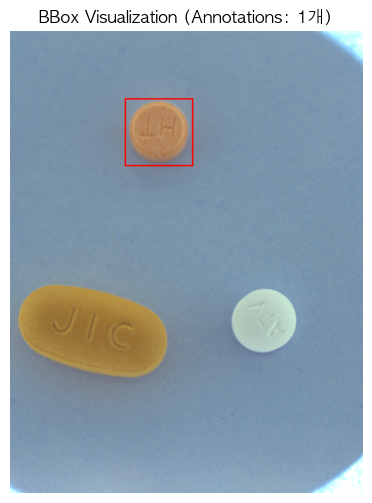

In [19]:
# 이미지 / 바운딩 박스 시각화

import json
import glob
import os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# 폰트 깨짐 방지 (맥 버전)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# JSON 및 이미지 파일 탐색
json_files = glob.glob("../data/**/*.json", recursive=True)

if json_files:
    sample_json_path = json_files[0]
    with open(sample_json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    if "images" in data and "annotations" in data and len(data["images"]) > 0:
        # 첫 번째 이미지 정보 가져오기
        img_info = data["images"][0]
        img_id = img_info.get("id")
        file_name = img_info.get("file_name", "")
        
        # 실제 이미지 파일 경로 찾기
        target_img_path = None
        found_paths = glob.glob(f"../data/**/*{os.path.basename(file_name)}", recursive=True)
        if found_paths:
            target_img_path = found_paths[0]
        else:
            # 파일명으로 못 찾으면 아무 이미지나 가져오기
            all_imgs = glob.glob("../data/**/*.jpg", recursive=True) + glob.glob("../data/**/*.png", recursive=True)
            if all_imgs:
                target_img_path = all_imgs[0]
                
        if target_img_path:
            print(f"시각화 대상 이미지: {target_img_path}")
            img = Image.open(target_img_path)
            draw = ImageDraw.Draw(img)
            
            # 해당 이미지의 바운딩 박스 추출
            matching_anns = [ann for ann in data["annotations"] if ann.get("image_id") == img_id]
            if not matching_anns:
                matching_anns = data["annotations"][:5] # ID 매칭 안되면 앞의 5개 샘플링
                
            for ann in matching_anns:
                bbox = ann.get("bbox") # [x, y, w, h] 포맷 가정
                if bbox and len(bbox) == 4:
                    x, y, w, h = bbox
                    # 빨간색 테두리로 바운딩 박스 그리기
                    draw.rectangle([x, y, x + w, y + h], outline="red", width=4)
            
            # 맷플롯립으로 출력
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"BBox Visualization (Annotations: {len(matching_anns)}개)")
            plt.show()
        else:
            print("시각화할 이미지 파일을 찾지 못함.")
    else:
        print("JSON 내에 images 또는 annotations 데이터가 부족함.")
else:
    print("JSON 파일을 찾지 못함.")

=== 이미지당 어노테이션(알약) 개수 통계 ===
count    763.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
dtype: float64


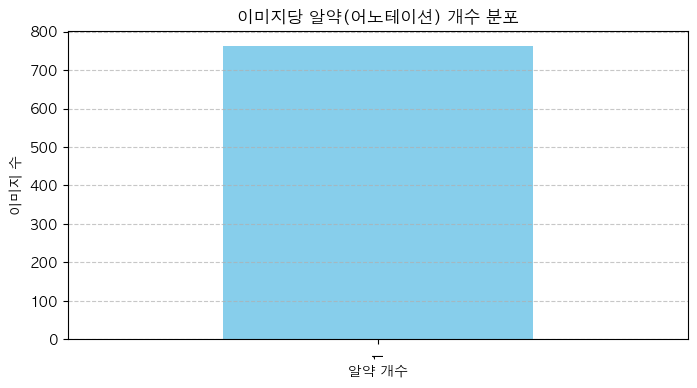

In [20]:
# 이미지별 어노테이션 개수 분포

import json
import glob
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# 맥북 환경 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

json_files = glob.glob("../data/**/*.json", recursive=True)

image_ann_counts = []

for jf in json_files:
    try:
        with open(jf, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        if "annotations" in data and "images" in data:
            # image_id별 어노테이션 개수 카운트
            ann_counts = Counter(ann.get("image_id") for ann in data["annotations"])
            
            # images 리스트를 돌며 각 이미지별 어노테이션 개수 수집 (없는 경우 0개)
            for img in data["images"]:
                img_id = img.get("id")
                image_ann_counts.append(ann_counts.get(img_id, 0))
    except Exception as e:
        print(f"파일 처리 오류 ({jf}): {e}")

if image_ann_counts:
    series_counts = pd.Series(image_ann_counts)
    print("=== 이미지당 어노테이션(알약) 개수 통계 ===")
    print(series_counts.describe())
    
    # 막대 그래프 시각화
    plt.figure(figsize=(8, 4))
    series_counts.value_counts().sort_index().plot(kind='bar', color='skyblue')
    plt.title("이미지당 알약(어노테이션) 개수 분포")
    plt.xlabel("알약 개수")
    plt.ylabel("이미지 수")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("어노테이션 데이터를 찾지 못함.")

=== 클래스별 어노테이션 개수 상위 10개 ===
   Category ID  Count
0         3351    153
1         3483     45
2        35206     37
3        16262     23
4        21325     22
5        16232     21
6         3832     20
7        20238     20
8        36637     19
9        38162     18

=== 클래스별 어노테이션 개수 하위 10개 ===
    Category ID  Count
46        19552      3
47        22362      3
48        34597      3
49        27926      3
50        31885      3
51        21771      3
52        33208      3
53        13395      3
54         3743      3
55        27777      3


<Figure size 1200x500 with 0 Axes>

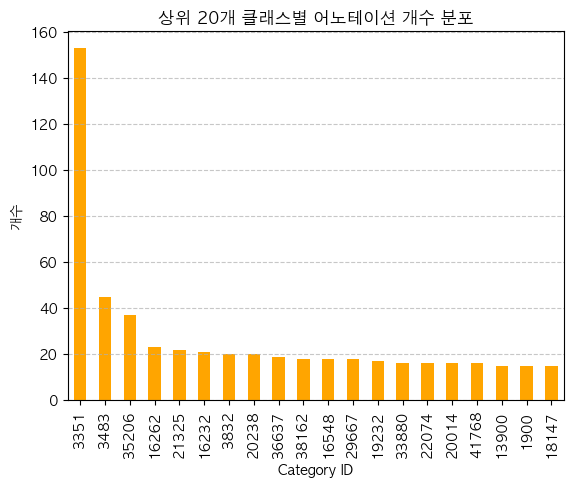

In [22]:
# 클래스별 어노테이션 개수 확인

import json
import glob
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# 맥북 환경 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

json_files = glob.glob("../data/**/*.json", recursive=True)

class_counts = Counter()

for jf in json_files:
    try:
        with open(jf, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        if "annotations" in data:
            for ann in data["annotations"]:
                # 카테고리 ID 또는 클래스 ID 수집 (키 이름에 따라 조정 가능)
                cat_id = ann.get("category_id")
                if cat_id is not None:
                    class_counts[cat_id] += 1
    except Exception as e:
        print(f"파일 처리 오류 ({jf}): {e}")

if class_counts:
    df_class = pd.DataFrame(list(class_counts.items()), columns=['Category ID', 'Count'])
    df_class = df_class.sort_values(by='Count', ascending=False).reset_index(drop=True)
    
    print("=== 클래스별 어노테이션 개수 상위 10개 ===")
    print(df_class.head(10))
    
    print("\n=== 클래스별 어노테이션 개수 하위 10개 ===")
    print(df_class.tail(10))
    
    # 상위 20개 클래스 분포 시각화
    plt.figure(figsize=(12, 5))
    df_class.head(20).plot(x='Category ID', y='Count', kind='bar', color='orange', legend=False)
    plt.title("상위 20개 클래스별 어노테이션 개수 분포")
    plt.xlabel("Category ID")
    plt.ylabel("개수")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("클래스 어노테이션 데이터를 찾지 못함.")

=== 이미지 평균 밝기 통계 ===
count    1074.000000
mean      122.388953
std        16.373011
min        91.614701
25%       110.305807
50%       117.972170
75%       132.603997
max       163.829935
dtype: float64


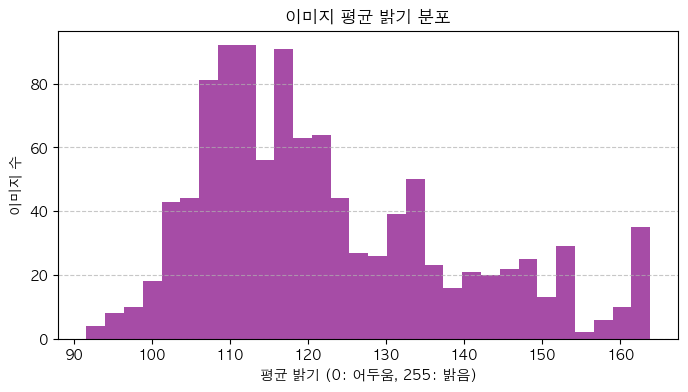

In [23]:
# 이비지 밝기 분포 확인

import glob
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 맥북 환경 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 모든 이미지 경로 탐색
image_paths = glob.glob("../data/**/*.jpg", recursive=True) + glob.glob("../data/**/*.png", recursive=True)

brightness_list = []

# 이미지 밝기(그레이스케일 평균값) 계산
for path in image_paths:
    try:
        with Image.open(path) as img:
            # 흑백으로 변환 후 픽셀 평균 밝기 계산 (0 ~ 255)
            gray_img = img.convert('L')
            arr = np.array(gray_img)
            brightness_list.append(arr.mean())
    except Exception as e:
        pass

if brightness_list:
    brightness_series = pd.Series(brightness_list)
    print("=== 이미지 평균 밝기 통계 ===")
    print(brightness_series.describe())
    
    # 히스토그램 시각화
    plt.figure(figsize=(8, 4))
    plt.hist(brightness_list, bins=30, color='purple', alpha=0.7)
    plt.title("이미지 평균 밝기 분포")
    plt.xlabel("평균 밝기 (0: 어두움, 255: 밝음)")
    plt.ylabel("이미지 수")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("이미지 밝기를 계산할 파일을 찾지 못함.")

In [24]:
# 테스트 / 전체 이미지 크기 다양성 확인

import glob
from PIL import Image
from collections import Counter

# 모든 이미지 경로 탐색
image_paths = glob.glob("../data/**/*.jpg", recursive=True) + glob.glob("../data/**/*.png", recursive=True)

size_counts = Counter()

for path in image_paths:
    try:
        with Image.open(path) as img:
            size_counts[img.size] += 1
    except Exception as e:
        pass

print("=== 이미지 해상도별 개수 분포 ===")
for size, count in size_counts.items():
    print(f"해상도 (가로, 세로): {size} -> 이미지 수: {count}개")

=== 이미지 해상도별 개수 분포 ===
해상도 (가로, 세로): (976, 1280) -> 이미지 수: 1074개


=== 바운딩 박스 크기 및 면적 통계 ===
            Width      Height           Area
count  763.000000  763.000000     763.000000
mean   250.007864  265.764089   70384.792923
std     73.772225   95.652529   42608.636579
min    125.000000  126.000000   23250.000000
25%    189.500000  191.000000   36672.000000
50%    230.000000  227.000000   53600.000000
75%    285.000000  316.000000   93492.500000
max    529.000000  664.000000  272435.000000


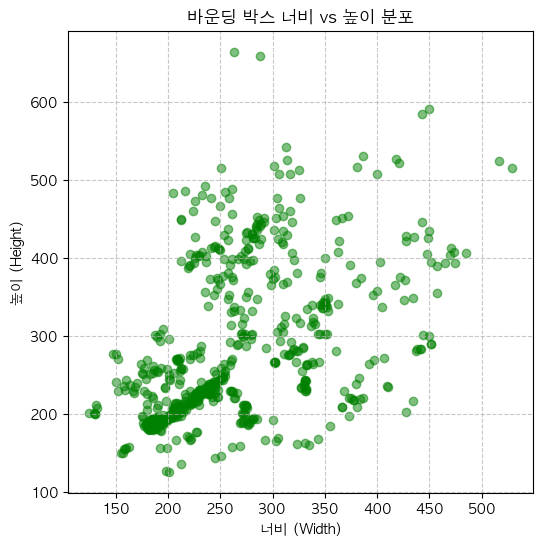

In [25]:
# 바운딩 박스 크기 및 비율 분포 확인

import json
import glob
import matplotlib.pyplot as plt
import pandas as pd

# 맥북 환경 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

json_files = glob.glob("../data/**/*.json", recursive=True)
widths, heights, areas = [], [], []

for jf in json_files:
    try:
        with open(jf, 'r', encoding='utf-8') as f:
            data = json.load(f)
        if "annotations" in data:
            for ann in data["annotations"]:
                bbox = ann.get("bbox") # [x, y, w, h] 포맷 가정
                if bbox and len(bbox) == 4:
                    _, _, w, h = bbox
                    widths.append(w)
                    heights.append(h)
                    areas.append(w * h)
    except Exception as e:
        pass

if widths:
    df_bbox = pd.DataFrame({"Width": widths, "Height": heights, "Area": areas})
    print("=== 바운딩 박스 크기 및 면적 통계 ===")
    print(df_bbox.describe())
    
    # 바운딩 박스 너비와 높이 산점도 시각화
    plt.figure(figsize=(6, 6))
    plt.scatter(widths, heights, alpha=0.5, color='green')
    plt.title("바운딩 박스 너비 vs 높이 분포")
    plt.xlabel("너비 (Width)")
    plt.ylabel("높이 (Height)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("바운딩 박스 데이터를 찾지 못함.")

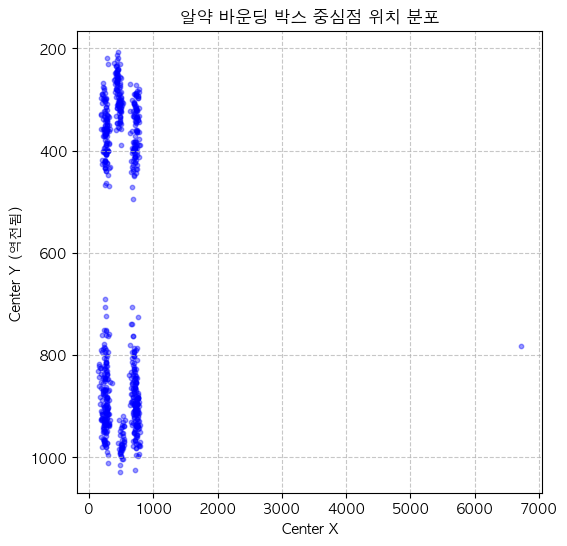

In [26]:
# 바운딩 박스 중심 좌표 분포 확인

import json
import glob
import matplotlib.pyplot as plt

# 맥북 환경 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

json_files = glob.glob("../data/**/*.json", recursive=True)
centers_x, centers_y = [], []

for jf in json_files:
    try:
        with open(jf, 'r', encoding='utf-8') as f:
            data = json.load(f)
        if "annotations" in data:
            for ann in data["annotations"]:
                bbox = ann.get("bbox") # [x, y, w, h] 포맷 가정
                if bbox and len(bbox) == 4:
                    x, y, w, h = bbox
                    # 박스의 중심점(Center X, Center Y) 계산
                    centers_x.append(x + w / 2)
                    centers_y.append(y + h / 2)
    except Exception as e:
        pass

if centers_x:
    plt.figure(figsize=(6, 6))
    # y축을 역전시켜 이미지 좌표계(상단이 0)와 일치시킴
    plt.scatter(centers_x, centers_y, alpha=0.4, color='blue', s=10)
    plt.gca().invert_yaxis()
    plt.title("알약 바운딩 박스 중심점 위치 분포")
    plt.xlabel("Center X")
    plt.ylabel("Center Y (역전됨)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("중심점 데이터를 찾지 못했습니다.")


In [27]:
# EDA 최종 요약 및 모델 훈련 준비 단계

print("=" * 50)
print(" 알약 탐지 데이터셋 EDA 최종 요약 리포트 ")
print("=" * 50)
print("1. 데이터 구조: 이미지당 정확히 1개의 알약이 존재하는 단일 객체 검출(Single-Object Detection) 구조")
print("2. 이미지 해상도: 976x1280 고해상도 (맥북 에어 MPS 학습 시 640x640 리사이징 권장)")
print("3. 이상치 발견: BBox 좌표 중 비정상적인 범위를 벗어난 아웃라이어 존재 확인 -> 전처리 시 필터링 필요")
print("4. 학습 환경 최적화: Apple Silicon(MPS) 가속 활용을 위한 배치 사이즈 조절 및 폰트/데이터 로더 설정 완료")
print("=" * 50)
print("모든 EDA 단계가 성공적으로 완료됨")

 알약 탐지 데이터셋 EDA 최종 요약 리포트 
1. 데이터 구조: 이미지당 정확히 1개의 알약이 존재하는 단일 객체 검출(Single-Object Detection) 구조
2. 이미지 해상도: 976x1280 고해상도 (맥북 에어 MPS 학습 시 640x640 리사이징 권장)
3. 이상치 발견: BBox 좌표 중 비정상적인 범위를 벗어난 아웃라이어 존재 확인 -> 전처리 시 필터링 필요
4. 학습 환경 최적화: Apple Silicon(MPS) 가속 활용을 위한 배치 사이즈 조절 및 폰트/데이터 로더 설정 완료
모든 EDA 단계가 성공적으로 완료됨
